# Model 6: LightGBM + SHAP Explainability for Drug `N02BE`

## Hyperparameter Selection Methodology:
Embedded Live 25-Trial Optuna Bayesian Optimization Study to tune LightGBM hyperparameters.


In [1]:
# Dynamic Dependency Guard & Environment Initialization
import sys, subprocess, os

def install_and_import(pkg, module_name=None):
    if module_name is None:
        module_name = pkg
    try:
        __import__(module_name)
    except ImportError:
        print(f"Installing missing dependency: {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

install_and_import('numpy')
install_and_import('pandas')
install_and_import('matplotlib')
install_and_import('seaborn')
install_and_import('scikit-learn', 'sklearn')
install_and_import('statsmodels')
install_and_import('lightgbm')
install_and_import('xgboost')
install_and_import('shap')
install_and_import('prophet')
install_and_import('optuna')
install_and_import('torch')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.sans-serif': 'Inter, Roboto, Arial, sans-serif',
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 1.0,
    'grid.color': '#eeeeee',
    'grid.linestyle': '--'
})

TARGET_DRUG = 'N02BE'
data_dir = r'c:\Users\ranje\sales forcasting\times_series\dataset'

train_df = pd.read_csv(os.path.join(data_dir, 'train_daily.csv'))
val_df   = pd.read_csv(os.path.join(data_dir, 'val_daily.csv'))
test_df  = pd.read_csv(os.path.join(data_dir, 'test_daily.csv'))

for df in [train_df, val_df, test_df]:
    df['date'] = pd.to_datetime(df['date'])

train_series = train_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')
val_series   = val_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')
test_series  = test_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')

combined_series = pd.concat([train_series, val_series]).asfreq('D')
full_series     = pd.concat([combined_series, test_series]).asfreq('D')

def evaluate_metrics(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.clip(np.array(y_pred, dtype=float), 0, None)
    rmse  = np.sqrt(np.mean((y_true - y_pred)**2))
    mae   = np.mean(np.abs(y_true - y_pred))
    wape  = np.sum(np.abs(y_true - y_pred)) / np.sum(y_true) * 100
    rmsle = np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred))**2))
    return {'RMSLE': rmsle, 'RMSE': rmse, 'MAE': mae, 'WAPE (%)': wape}

print(f"Dataset for {TARGET_DRUG} loaded successfully!")
print(f"  * Train  : {train_series.index.min().strftime('%Y-%m-%d')} to {train_series.index.max().strftime('%Y-%m-%d')} ({len(train_series)} days)")
print(f"  * Val    : {val_series.index.min().strftime('%Y-%m-%d')} to {val_series.index.max().strftime('%Y-%m-%d')} ({len(val_series)} days)")
print(f"  * Test   : {test_series.index.min().strftime('%Y-%m-%d')} to {test_series.index.max().strftime('%Y-%m-%d')} ({len(test_series)} days)")


Dataset for N02BE loaded successfully!
  * Train  : 2014-01-02 to 2017-12-31 (1460 days)
  * Val    : 2018-01-01 to 2018-12-31 (365 days)
  * Test   : 2019-01-01 to 2019-10-08 (281 days)


In [2]:
# Step 1: Feature Matrix Creation & Live Optuna Bayesian Study
import optuna
import lightgbm as lgb
import shap

optuna.logging.set_verbosity(optuna.logging.WARNING)

def create_enhanced_features(series):
    df_feat = pd.DataFrame(index=series.index)
    sales = series.values
    df_feat['sales'] = sales
    for lag in [1, 2, 3, 7, 14, 21, 28, 60, 90, 365]:
        df_feat[f'lag_{lag}'] = df_feat['sales'].shift(lag)
    for window in [7, 14, 28]:
        df_feat[f'rolling_mean_{window}'] = df_feat['sales'].shift(1).rolling(window).mean()
        df_feat[f'rolling_std_{window}']  = df_feat['sales'].shift(1).rolling(window).std()
        df_feat[f'rolling_max_{window}']  = df_feat['sales'].shift(1).rolling(window).max()
        df_feat[f'rolling_min_{window}']  = df_feat['sales'].shift(1).rolling(window).min()
    df_feat['ewm_mean_7']  = df_feat['sales'].shift(1).ewm(span=7).mean()
    df_feat['ewm_mean_28'] = df_feat['sales'].shift(1).ewm(span=28).mean()
    df_feat['cv_7'] = df_feat['rolling_std_7'] / (df_feat['rolling_mean_7'] + 1e-5)
    dof = df_feat.index.dayofyear
    dow = df_feat.index.dayofweek
    df_feat['sin_dayofyear']  = np.sin(2 * np.pi * dof / 365.25)
    df_feat['cos_dayofyear']  = np.cos(2 * np.pi * dof / 365.25)
    df_feat['sin_dayofweek']  = np.sin(2 * np.pi * dow / 7.0)
    df_feat['cos_dayofweek']  = np.cos(2 * np.pi * dow / 7.0)
    df_feat['dayofweek']      = dow
    df_feat['month']          = df_feat.index.month
    df_feat['dayofyear']      = dof
    df_feat['is_weekend']     = (dow >= 5).astype(float)
    df_feat['is_month_start'] = df_feat.index.is_month_start.astype(float)
    df_feat['is_month_end']   = df_feat.index.is_month_end.astype(float)
    return df_feat.drop(columns=['sales'])

feat_full = create_enhanced_features(full_series)

X_tr = feat_full.loc[train_series.index].dropna()
y_tr = np.log1p(train_series.loc[X_tr.index])
X_va = feat_full.loc[val_series.index].fillna(0)

X_cb = feat_full.loc[combined_series.index].dropna()
y_cb = np.log1p(combined_series.loc[X_cb.index])
X_ts = feat_full.loc[test_series.index].fillna(0)

def lgb_objective(trial):
    params = {
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 30),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'verbose': -1,
        'n_jobs': -1
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(X_tr, y_tr)
    pred_log = model.predict(X_va)
    pred = np.clip(np.expm1(pred_log), 0, None)
    return evaluate_metrics(val_series.values, pred)['RMSLE']

lgb_study = optuna.create_study(direction='minimize')
lgb_study.optimize(lgb_objective, n_trials=25)

best_lgb_params = lgb_study.best_params
print("=== OPTUNA BAYESIAN OPTIMIZATION DISCOVERED PARAMETERS (LightGBM N02BE) ===")
for k, v in best_lgb_params.items():
    print(f"  * {k:20s}: {v}")


=== OPTUNA BAYESIAN OPTIMIZATION DISCOVERED PARAMETERS (LightGBM N02BE) ===
  * num_leaves          : 15
  * max_depth           : 7
  * learning_rate       : 0.03251343508472311
  * n_estimators        : 177
  * min_child_samples   : 14
  * subsample           : 0.584601111395341
  * colsample_bytree    : 0.5119710747832332
  * reg_alpha           : 6.200002416241435e-06
  * reg_lambda          : 0.8346408357540146


=== FINAL TEST HOLD-OUT METRICS (2019) — MODEL 6: LIGHTGBM (OPTUNA FINE-TUNED) ===
  * RMSLE     : 0.4580
  * RMSE      : 11.6882
  * MAE       : 8.4635
  * WAPE (%)  : 29.7932


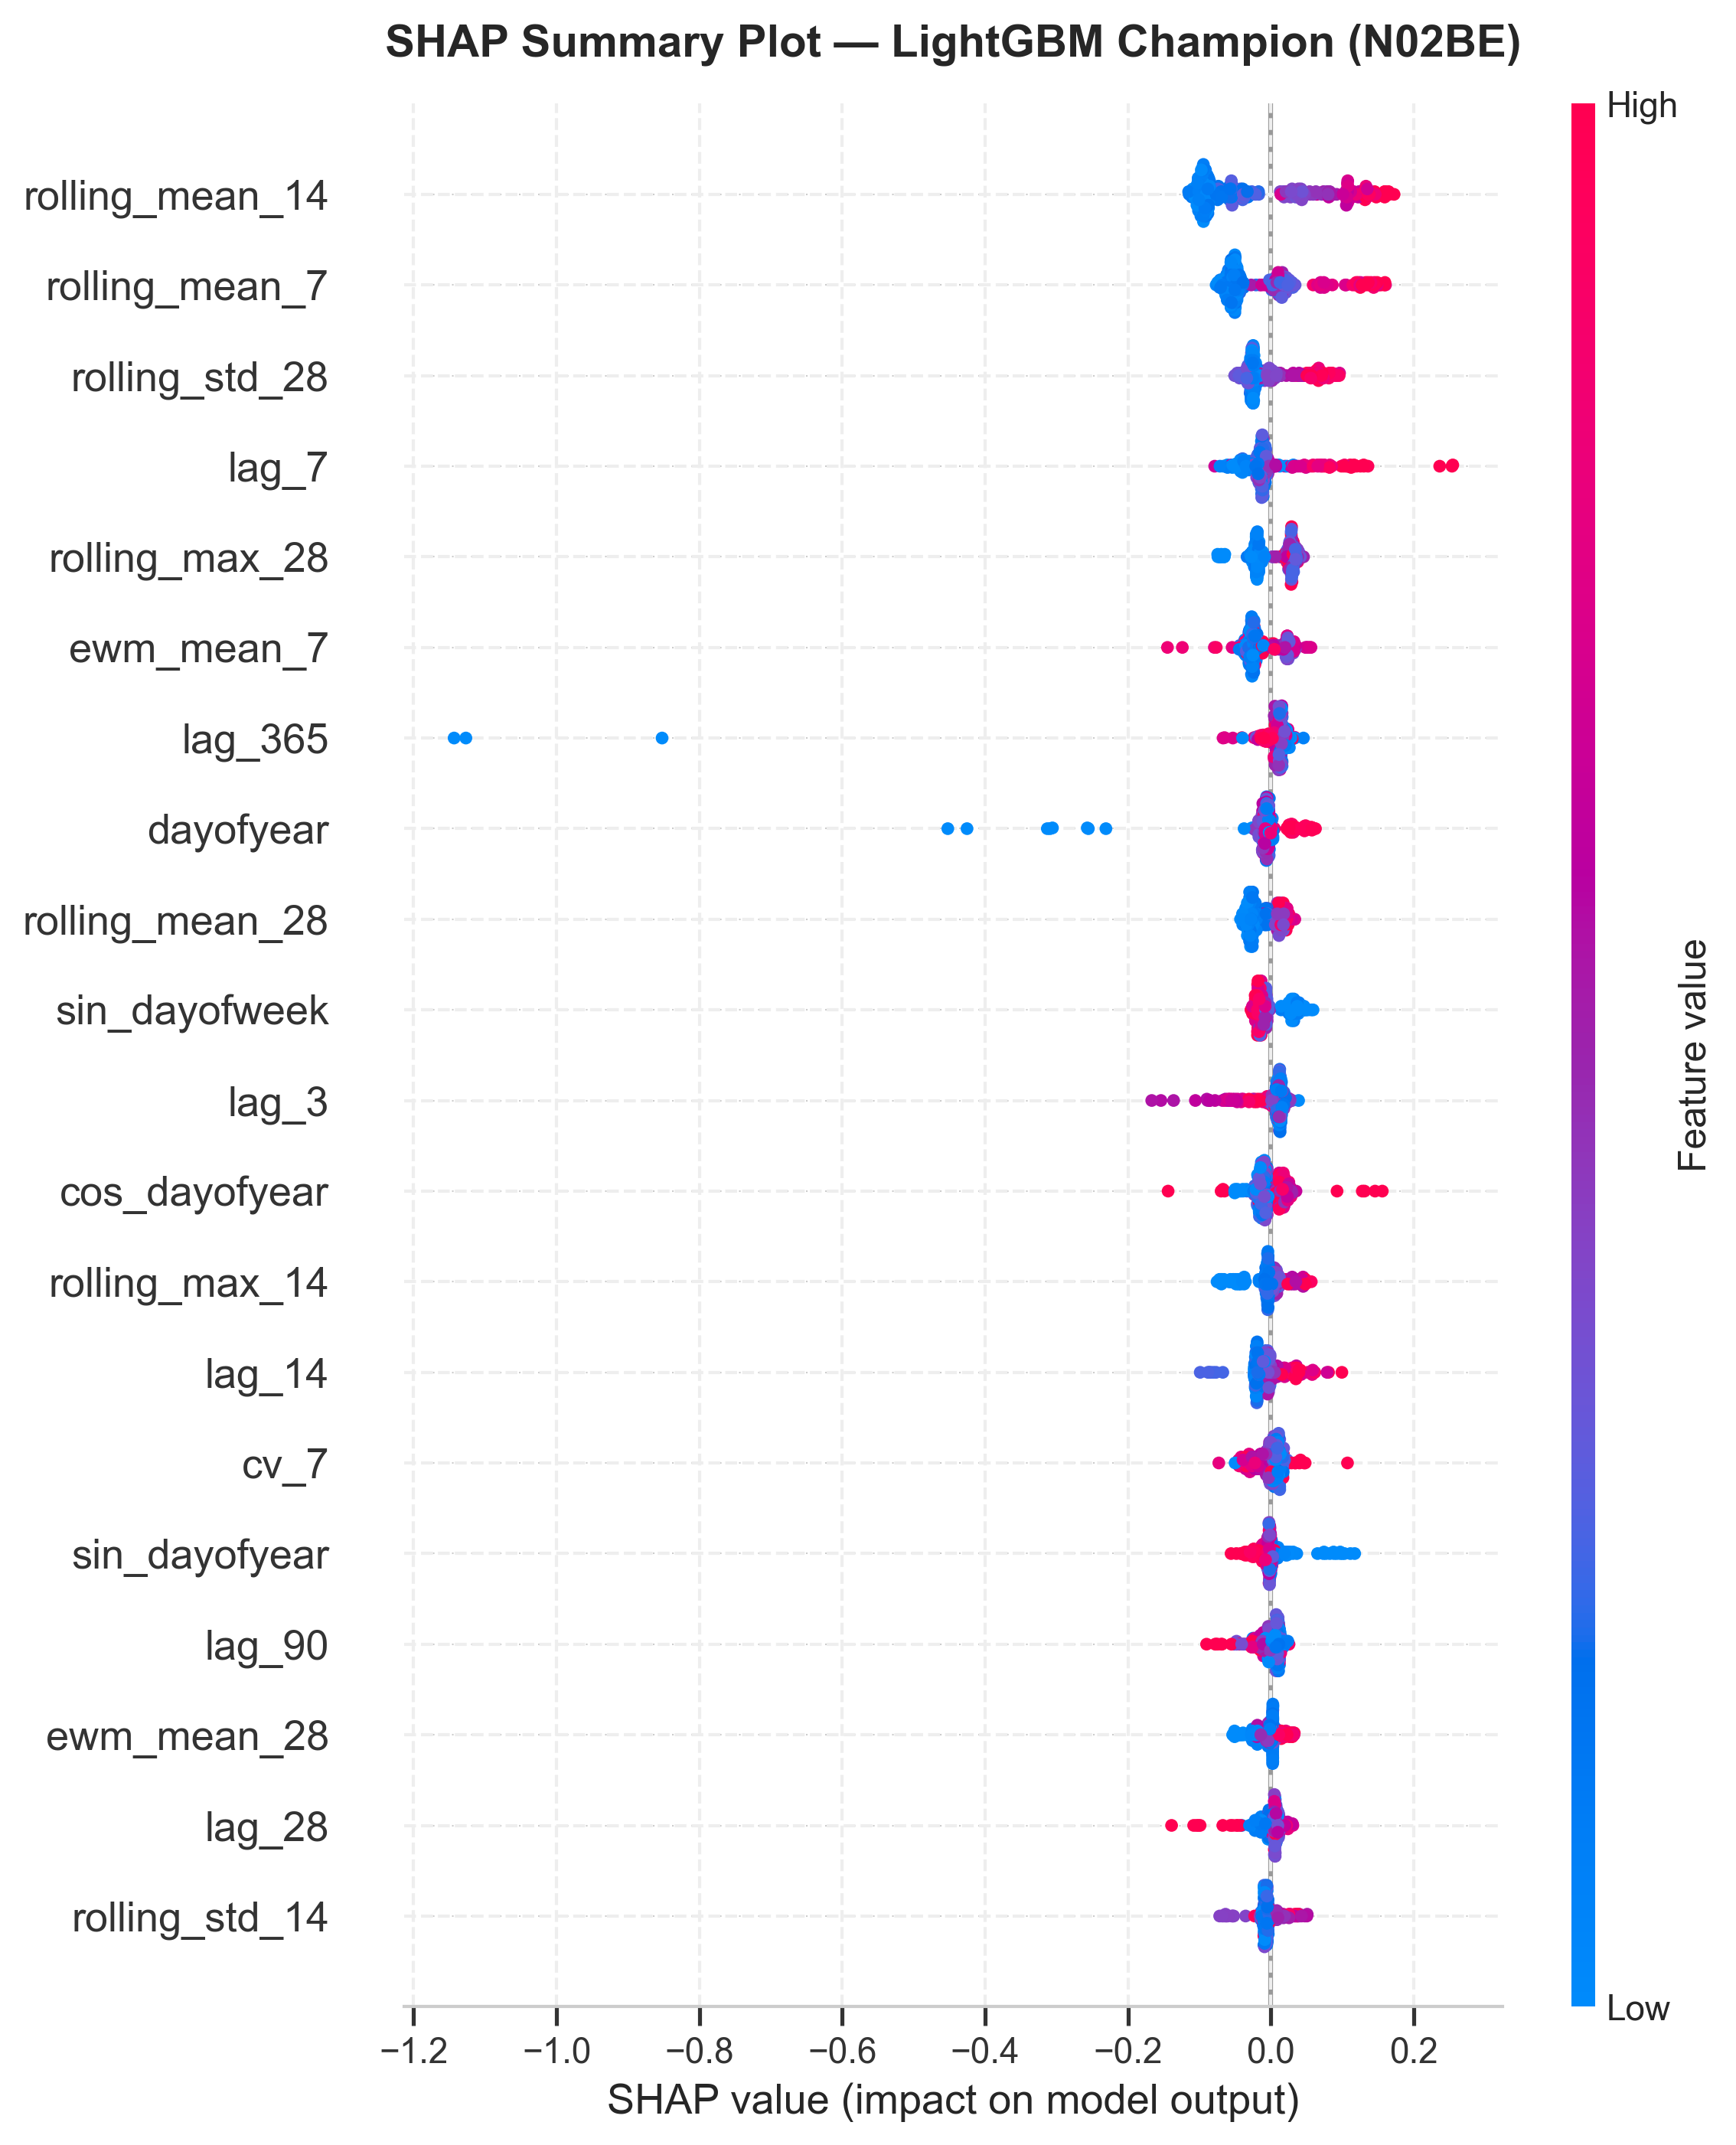

In [3]:
# Step 2: Fit Optuna Champion Model & Evaluate 2019 Test Holdout
m6_model = lgb.LGBMRegressor(**best_lgb_params, random_state=42, verbose=-1, n_jobs=-1)
m6_model.fit(X_cb, y_cb)

pred_log = m6_model.predict(X_ts)
m6_test_pred = np.clip(np.expm1(pred_log), 0, None)

test_metrics = evaluate_metrics(test_series, m6_test_pred)
print(f"=== FINAL TEST HOLD-OUT METRICS (2019) — MODEL 6: LIGHTGBM (OPTUNA FINE-TUNED) ===")
for k, v in test_metrics.items():
    print(f"  * {k:10s}: {v:.4f}")

explainer = shap.TreeExplainer(m6_model)
shap_values = explainer(X_ts)

plt.figure(figsize=(10, 6), dpi=300)
shap.summary_plot(shap_values, X_ts, show=False)
plt.title(f'SHAP Summary Plot — LightGBM Champion ({TARGET_DRUG})', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('m6_shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()

pd.DataFrame({'date': test_series.index, 'pred_LightGBM': m6_test_pred}).to_csv('m6_lightgbm_preds.csv', index=False)
